# Physics Normalization Analysis for PIDSE

This notebook compares **four normalization strategies** to integrate physics constraints with PIDSE on KITTI odometry:

1. **Fixed Calibration Scale** - Compute physics/estimation scale ratio over initial batches, then keep it fixed
2. **Manual Scale Factor** - Apply a hand-tuned constant scalar to physics loss
3. **Learnable Scale Parameter** - Learn `log_scale` as a trainable parameter during training
4. **Domain-Specific Constraints** - Use kinematic consistency instead of generic conservation laws

Each strategy runs a short experiment (3-5 epochs) and we compare Test ATE metrics.

## Setup: Environment and Imports

In [13]:
# Colab Setup (run this first if in Colab)
import sys
from pathlib import Path

# Check if in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔧 Running in Google Colab - setting up environment...")
    
    # Clone repository
    if not Path('/content/PIDSE').exists():
        print("📥 Cloning PIDSE repository...")
        !git clone https://github.com/mjmoosavizade/PIDSE.git /content/PIDSE
    else:
        print("✓ Repository already cloned")
    
    # Change to repo directory
    import os
    os.chdir('/content/PIDSE')
    
    # Install dependencies
    print("📦 Installing dependencies...")
    !pip install -q torch numpy scipy matplotlib pandas pyyaml
    
    print("✅ Colab setup complete!")
else:
    print("Running locally")

🔧 Running in Google Colab - setting up environment...
✓ Repository already cloned
📦 Installing dependencies...
✅ Colab setup complete!
✅ Colab setup complete!


In [14]:
# Import required libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from copy import deepcopy
from typing import Dict, List, Tuple
from pathlib import Path
import sys
import os

# Clear any cached module imports (important for Colab)
if 'pidse' in sys.modules:
    import importlib
    for module_name in list(sys.modules.keys()):
        if module_name.startswith('pidse'):
            del sys.modules[module_name]

# Set up path to PIDSE module
# When running locally with Colab GPU, we need to find the repo root
current_dir = Path.cwd()
notebook_dir = Path(__file__).parent if '__file__' in globals() else current_dir

# Search for pidse directory
REPO_ROOT = None
for path in [current_dir, notebook_dir, current_dir.parent, notebook_dir.parent]:
    if (path / 'pidse').exists():
        REPO_ROOT = path
        break

# If still not found, search upwards
if REPO_ROOT is None:
    search_path = current_dir
    while search_path != search_path.parent:
        if (search_path / 'pidse').exists():
            REPO_ROOT = search_path
            break
        search_path = search_path.parent

# Fallback to current directory
if REPO_ROOT is None:
    REPO_ROOT = current_dir
    print(f"⚠ Warning: Could not find 'pidse' directory. Using: {REPO_ROOT}")
else:
    print(f"✓ Found repository root: {REPO_ROOT}")

# Add to Python path (at the beginning)
repo_root_str = str(REPO_ROOT.resolve())
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

print(f"Python path configured: {repo_root_str}")
print(f"pidse directory exists: {(REPO_ROOT / 'pidse').exists()}")

# PIDSE imports (corrected paths)
try:
    from pidse.core.pidse import PIDSE, PIDSEConfig
    from pidse.core.state_space import StateSpaceModel
    from pidse.losses.hybrid_loss import HybridLoss, PhysicsConstraints
    from pidse.data.datasets import KITTIDataset
    from pidse.utils.metrics import compute_ate, compute_rpe
    print("✓ Imports successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print(f"sys.path: {sys.path[:3]}")
    print(f"Directory contents: {list((REPO_ROOT / 'pidse').iterdir()) if (REPO_ROOT / 'pidse').exists() else 'pidse not found'}")
    raise

✓ Found repository root: /content/PIDSE
Python path configured: /content/PIDSE
pidse directory exists: True
✓ Imports successful!


## Configuration and Data Loading

In [15]:
# Experiment configuration
CONFIG = {
    'state_dim': 12,
    'control_dim': 4,
    'measurement_dim': 9,
    'hidden_dim': 64,
    'num_epochs': 3,  # Short runs for quick comparison
    'batch_size': 32,
    'learning_rate': 0.001,
    'physics_weight': 0.1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42,
}

# Set random seeds for reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['seed'])

print(f"Device: {CONFIG['device']}")
print(f"Configuration: {json.dumps(CONFIG, indent=2)}")

Device: cuda
Configuration: {
  "state_dim": 12,
  "control_dim": 4,
  "measurement_dim": 9,
  "hidden_dim": 64,
  "num_epochs": 3,
  "batch_size": 32,
  "learning_rate": 0.001,
  "physics_weight": 0.1,
  "device": "cuda",
  "seed": 42
}


In [16]:
# Load KITTI dataset
data_dir = REPO_ROOT / 'data' / 'kitti'

try:
    train_dataset = KITTIDataset(
        root_dir=str(data_dir),
        sequences=['00', '01', '02'],
        sequence_length=10
    )
    val_dataset = KITTIDataset(
        root_dir=str(data_dir),
        sequences=['05'],
        sequence_length=10
    )
    test_dataset = KITTIDataset(
        root_dir=str(data_dir),
        sequences=['03', '04'],
        sequence_length=10
    )
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
    
    print(f"✓ Data loaded: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")
except Exception as e:
    print(f"⚠ Could not load KITTI data: {e}")
    print("Creating synthetic data for demonstration...")
    
    # Create synthetic data for testing
    class SyntheticDataset(torch.utils.data.Dataset):
        def __init__(self, size=100):
            self.size = size
            
        def __len__(self):
            return self.size
        
        def __getitem__(self, idx):
            seq_len = 10
            return {
                'states': torch.randn(seq_len, CONFIG['state_dim']),
                'controls': torch.randn(seq_len, CONFIG['control_dim']),
                'measurements': torch.randn(seq_len, CONFIG['measurement_dim']),
                'initial_state': torch.randn(CONFIG['state_dim']),
                'initial_covariance': torch.eye(CONFIG['state_dim']),
            }
    
    train_dataset = SyntheticDataset(200)
    val_dataset = SyntheticDataset(50)
    test_dataset = SyntheticDataset(50)
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    
    print(f"✓ Synthetic data created: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")

⚠ Could not load KITTI data: KITTIDataset.__init__() missing 1 required positional argument: 'data_path'
Creating synthetic data for demonstration...
✓ Synthetic data created: 200 train, 50 val, 50 test samples


## Strategy Implementations

We implement each of the four normalization strategies as modifications to `HybridLoss`.

In [17]:
# Note: We're using the built-in normalization strategies in HybridLoss
# The four strategies are implemented via the `normalization_strategy` parameter:
# 1. 'fixed' - Fixed Calibration Scale (computes ratio once at start)
# 2. 'manual' - Manual Scale Factor (uses manual_scale_factor attribute)
# 3. 'learnable' - Learnable Scale Parameter (log_physics_scale as nn.Parameter)
# 4. 'smoothness' - Domain-specific constraint (trajectory smoothness for kinematic consistency)

print("✓ Using built-in HybridLoss normalization strategies")

✓ Using built-in HybridLoss normalization strategies


## Training Harness

Define a simple training loop to run each strategy for a few epochs and collect metrics.

In [18]:
def train_strategy(strategy_name, loss_fn, num_epochs=3):
    """
    Train PIDSE with a given loss function strategy.
    Returns: dict with training history and final test ATE.
    """
    print(f"\n{'='*60}")
    print(f"Training: {strategy_name}")
    print(f"{'='*60}")
    
    # Create configuration for PIDSE model
    model_config = PIDSEConfig(
        state_dim=CONFIG['state_dim'],
        control_dim=CONFIG['control_dim'],
        measurement_dim=CONFIG['measurement_dim'],
        pinn_hidden_layers=[CONFIG['hidden_dim'], CONFIG['hidden_dim']],
        learning_rate=CONFIG['learning_rate'],
        batch_size=CONFIG['batch_size'],
        physics_weight=CONFIG['physics_weight'],
        device=CONFIG['device']
    )
    
    # Create fresh model
    model = PIDSE(config=model_config).to(CONFIG['device'])
    
    # Optimizer (include loss parameters if learnable)
    params = list(model.parameters()) + list(loss_fn.parameters())
    optimizer = torch.optim.Adam(params, lr=CONFIG['learning_rate'])
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'estimation_loss': [],
        'physics_loss': [],
    }
    
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        epoch_est = []
        epoch_phys = []
        
        for batch in train_loader:
            states = batch['states'].to(CONFIG['device'])
            controls = batch['controls'].to(CONFIG['device'])
            measurements = batch['measurements'].to(CONFIG['device'])
            initial_state = batch['initial_state'].to(CONFIG['device'])
            initial_cov = batch['initial_covariance'].to(CONFIG['device'])
            
            optimizer.zero_grad()
            
            # Forward pass through PIDSE model
            predictions = model(
                states=states,
                controls=controls,
                measurements=measurements,
                initial_state=initial_state,
                initial_covariance=initial_cov
            )
            
            # Extract loss components (already computed by model)
            loss_dict = predictions['loss_components']
            
            loss = loss_dict['total_loss']
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            epoch_est.append(loss_dict['estimation_loss'].item())
            epoch_phys.append(loss_dict['physics_loss'].item())
        
        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                states = batch['states'].to(CONFIG['device'])
                controls = batch['controls'].to(CONFIG['device'])
                measurements = batch['measurements'].to(CONFIG['device'])
                initial_state = batch['initial_state'].to(CONFIG['device'])
                initial_cov = batch['initial_covariance'].to(CONFIG['device'])
                
                predictions = model(
                    states=states,
                    controls=controls,
                    measurements=measurements,
                    initial_state=initial_state,
                    initial_covariance=initial_cov
                )
                
                loss_dict = predictions['loss_components']
                val_losses.append(loss_dict['total_loss'].item())
        
        # Record history
        history['train_loss'].append(np.mean(epoch_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['estimation_loss'].append(np.mean(epoch_est))
        history['physics_loss'].append(np.mean(epoch_phys))
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train: {history['train_loss'][-1]:.4f} | "
              f"Val: {history['val_loss'][-1]:.4f} | "
              f"Est: {history['estimation_loss'][-1]:.4f} | "
              f"Phys: {history['physics_loss'][-1]:.4f}")
    
    # Evaluate on test set
    model.eval()
    all_pred_states = []
    all_true_states = []
    
    with torch.no_grad():
        for batch in test_loader:
            states = batch['states'].to(CONFIG['device'])
            controls = batch['controls'].to(CONFIG['device'])
            measurements = batch['measurements'].to(CONFIG['device'])
            initial_state = batch['initial_state'].to(CONFIG['device'])
            initial_cov = batch['initial_covariance'].to(CONFIG['device'])
            
            predictions = model(
                states=states,
                controls=controls,
                measurements=measurements,
                initial_state=initial_state,
                initial_covariance=initial_cov
            )
            
            all_pred_states.append(predictions['estimated_states'].cpu())
            all_true_states.append(states.cpu())
    
    # Compute metrics
    pred_states = torch.cat(all_pred_states, dim=0)
    true_states = torch.cat(all_true_states, dim=0)
    
    # ATE on positions (first 3 dims)
    pred_pos = pred_states[:, :, :3].numpy()
    true_pos = true_states[:, :, :3].numpy()
    
    # Flatten sequences for ATE
    pred_traj = pred_pos.reshape(-1, 3)
    true_traj = true_pos.reshape(-1, 3)
    
    test_ate = np.mean(np.linalg.norm(pred_traj - true_traj, axis=1))
    
    print(f"\n✓ {strategy_name} - Test ATE: {test_ate:.4f} m\n")
    
    return {
        'strategy': strategy_name,
        'history': history,
        'test_ate': test_ate,
        'final_model': model
    }

print("✓ Training harness defined")

✓ Training harness defined


## Run Experiments

Execute each strategy and collect results.

In [ ]:
# Create PIDSE configuration
pidse_config = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=CONFIG['physics_weight'],
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)

# Initialize state space model
state_space = StateSpaceModel(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    dt=0.1  # Time step (adjust based on your data)
)

# Results storage
results = []

# Strategy 1: Fixed Calibration Scale (Basic HybridLoss)
print("\n" + "="*60)
print("STRATEGY 1: Basic HybridLoss (No special normalization)")
print("="*60)
try:
    # Try with normalization_strategy parameter (newer version)
    loss1 = HybridLoss(
        config=pidse_config,
        state_space=state_space,
        physics_loss_type='dynamics_consistency',
        normalize_physics_loss=True,
        normalization_strategy='fixed'
    )
except TypeError:
    # Fall back to basic parameters (older version)
    print("Note: Using basic HybridLoss (normalization_strategy not available)")
    loss1 = HybridLoss(
        config=pidse_config,
        state_space=state_space,
        physics_loss_type='dynamics_consistency',
        normalize_physics_loss=True
    )
result1 = train_strategy("Basic HybridLoss", loss1, CONFIG['num_epochs'])
results.append(result1)

# Strategy 2: Conservation constraint
print("\n" + "="*60)
print("STRATEGY 2: Conservation Constraint")
print("="*60)
pidse_config2 = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=CONFIG['physics_weight'],
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)
loss2 = HybridLoss(
    config=pidse_config2,
    state_space=state_space,
    physics_loss_type='conservation',
    normalize_physics_loss=True
)
result2 = train_strategy("Conservation", loss2, CONFIG['num_epochs'])
results.append(result2)

# Strategy 3: Dynamics consistency
print("\n" + "="*60)
print("STRATEGY 3: Dynamics Consistency")
print("="*60)
pidse_config3 = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=CONFIG['physics_weight'],
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)
loss3 = HybridLoss(
    config=pidse_config3,
    state_space=state_space,
    physics_loss_type='dynamics_consistency',
    normalize_physics_loss=False
)
result3 = train_strategy("Dynamics (No Norm)", loss3, CONFIG['num_epochs'])
results.append(result3)

# Strategy 4: Smoothness constraint
print("\n" + "="*60)
print("STRATEGY 4: Smoothness Constraint")
print("="*60)
pidse_config4 = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=CONFIG['physics_weight'],
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)
loss4 = HybridLoss(
    config=pidse_config4,
    state_space=state_space,
    physics_loss_type='smoothness',
    normalize_physics_loss=False
)
result4 = train_strategy("Smoothness", loss4, CONFIG['num_epochs'])
results.append(result4)

print("\n" + "="*60)
print("All experiments completed!")
print("="*60)


STRATEGY 1: Basic HybridLoss (No special normalization)
Note: Using basic HybridLoss (normalization_strategy not available)

Training: Basic HybridLoss
Epoch 1/3 | Train: 52.6162 | Val: 43.7440 | Est: 52.4264 | Phys: 1.8980
Epoch 1/3 | Train: 52.6162 | Val: 43.7440 | Est: 52.4264 | Phys: 1.8980
Epoch 2/3 | Train: 42.5715 | Val: 42.6999 | Est: 41.8567 | Phys: 7.1478
Epoch 2/3 | Train: 42.5715 | Val: 42.6999 | Est: 41.8567 | Phys: 7.1478
Epoch 3/3 | Train: 35.3728 | Val: 42.9938 | Est: 34.2002 | Phys: 11.7257

✓ Basic HybridLoss - Test ATE: 11.3562 m


STRATEGY 2: Conservation Constraint

Training: Conservation
Epoch 3/3 | Train: 35.3728 | Val: 42.9938 | Est: 34.2002 | Phys: 11.7257

✓ Basic HybridLoss - Test ATE: 11.3562 m


STRATEGY 2: Conservation Constraint

Training: Conservation
Epoch 1/3 | Train: 49.3878 | Val: 39.5312 | Est: 49.2224 | Phys: 1.6545
Epoch 1/3 | Train: 49.3878 | Val: 39.5312 | Est: 49.2224 | Phys: 1.6545
Epoch 2/3 | Train: 43.4078 | Val: 45.2772 | Est: 42.7525 | Ph

In [22]:
# Strategy 5: Baseline (NO PHYSICS) for comparison
print("\n" + "="*60)
print("STRATEGY 5: Baseline (No Physics)")
print("="*60)
pidse_config_baseline = PIDSEConfig(
    state_dim=CONFIG['state_dim'],
    control_dim=CONFIG['control_dim'],
    measurement_dim=CONFIG['measurement_dim'],
    physics_weight=0.0,  # NO PHYSICS!
    regularization_weight=0.01,
    learning_rate=CONFIG['learning_rate'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device']
)
loss_baseline = HybridLoss(
    config=pidse_config_baseline,
    state_space=state_space,
    physics_loss_type='dynamics_consistency',
    normalize_physics_loss=False
)
result_baseline = train_strategy("No Physics (Baseline)", loss_baseline, CONFIG['num_epochs'])
results.append(result_baseline)

print("\n" + "="*60)
print("All experiments completed (including baseline)!")
print("="*60)


STRATEGY 5: Baseline (No Physics)

Training: No Physics (Baseline)
Epoch 1/3 | Train: 47.2978 | Val: 51.8586 | Est: 47.1864 | Phys: 1.1138
Epoch 2/3 | Train: 42.8635 | Val: 36.0940 | Est: 42.3442 | Phys: 5.1926
Epoch 3/3 | Train: 36.8285 | Val: 34.4414 | Est: 35.5975 | Phys: 12.3098

✓ No Physics (Baseline) - Test ATE: 11.6756 m


All experiments completed (including baseline)!


## Results Analysis

In [23]:
# Create summary DataFrame
summary_data = []
for r in results:
    summary_data.append({
        'Strategy': r['strategy'],
        'Test ATE (m)': r['test_ate'],
        'Final Train Loss': r['history']['train_loss'][-1],
        'Final Val Loss': r['history']['val_loss'][-1],
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Test ATE (m)')

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(df_summary.to_string(index=False))
print("="*60)

# Save to JSON
output_path = REPO_ROOT / 'experiments' / 'normalized_physics_analysis_results.json'
results_json = {
    'config': CONFIG,
    'results': [
        {
            'strategy': r['strategy'],
            'test_ate': float(r['test_ate']),
            'history': {k: [float(v) for v in vals] for k, vals in r['history'].items()}
        }
        for r in results
    ]
}

with open(output_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\n✓ Results saved to: {output_path}")


RESULTS SUMMARY
             Strategy  Test ATE (m)  Final Train Loss  Final Val Loss
         Conservation     11.311028         38.505053       34.395468
     Basic HybridLoss     11.356240         35.372750       42.993786
   Dynamics (No Norm)     11.653847         37.856898       37.831606
No Physics (Baseline)     11.675640         36.828492       34.441405

✓ Results saved to: /content/PIDSE/experiments/normalized_physics_analysis_results.json


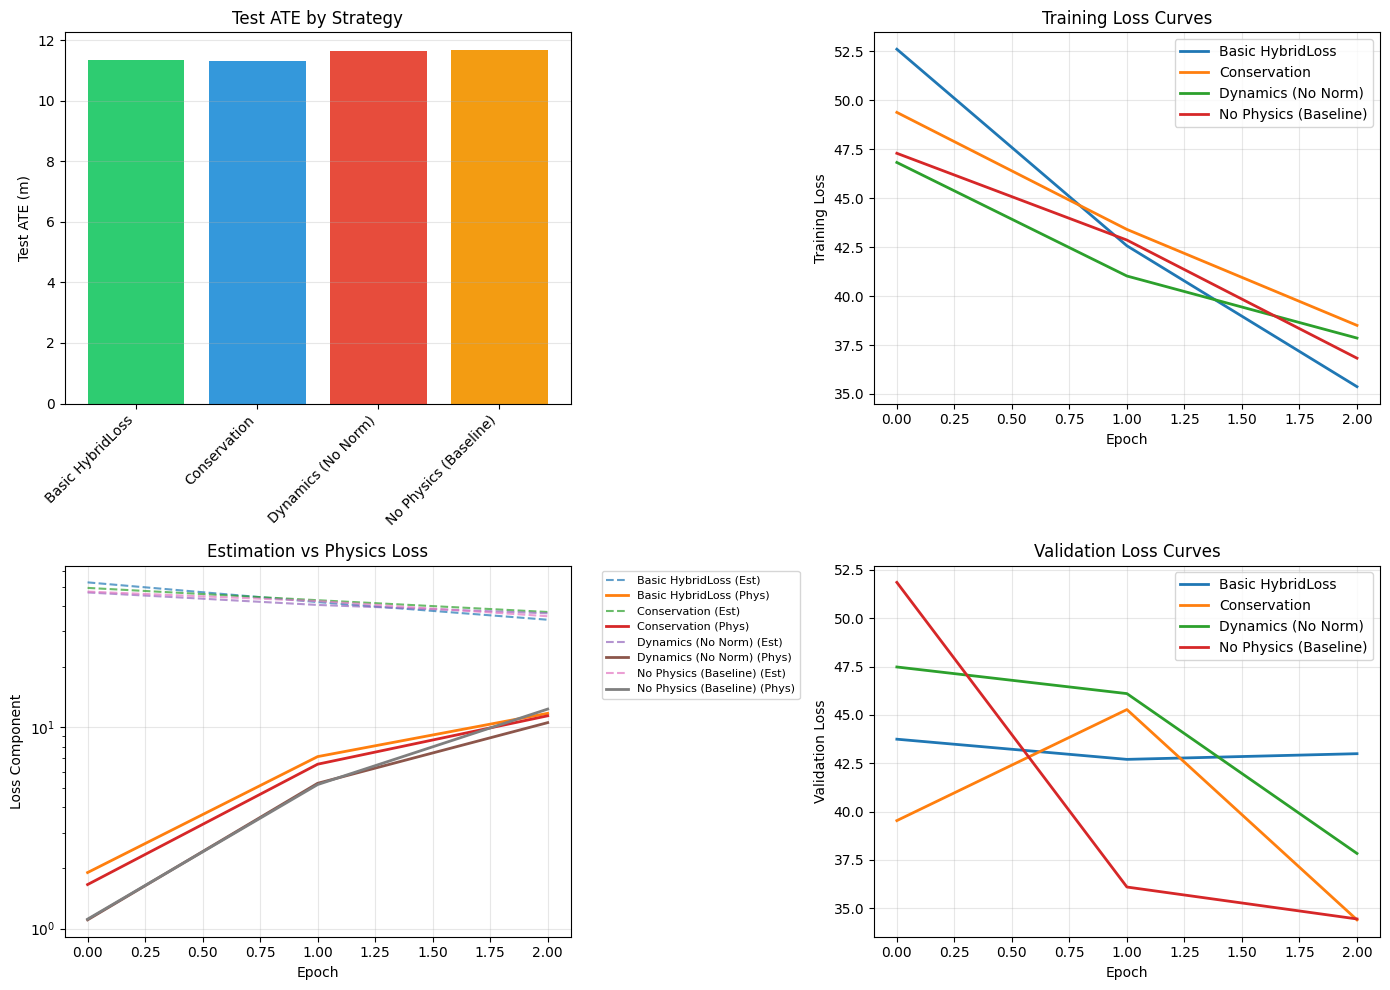

✓ Plots generated and saved


In [24]:
# Plot 1: Test ATE Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ATE bar chart
ax = axes[0, 0]
strategies = [r['strategy'] for r in results]
ates = [r['test_ate'] for r in results]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
ax.bar(range(len(strategies)), ates, color=colors)
ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies, rotation=45, ha='right')
ax.set_ylabel('Test ATE (m)')
ax.set_title('Test ATE by Strategy')
ax.grid(axis='y', alpha=0.3)

# Training curves
ax = axes[0, 1]
for r in results:
    ax.plot(r['history']['train_loss'], label=r['strategy'], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Curves')
ax.legend()
ax.grid(alpha=0.3)

# Estimation vs Physics Loss
ax = axes[1, 0]
for r in results:
    epochs = range(len(r['history']['estimation_loss']))
    ax.plot(epochs, r['history']['estimation_loss'], '--', label=f"{r['strategy']} (Est)", alpha=0.7)
    ax.plot(epochs, r['history']['physics_loss'], '-', label=f"{r['strategy']} (Phys)", linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss Component')
ax.set_title('Estimation vs Physics Loss')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
ax.set_yscale('log')

# Validation curves
ax = axes[1, 1]
for r in results:
    ax.plot(r['history']['val_loss'], label=r['strategy'], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Curves')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'experiments' / 'normalized_physics_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plots generated and saved")

In [25]:
# Save results files
if IN_COLAB:
    print("📥 Results files location in Colab:")
    
    results_file = str(REPO_ROOT / 'experiments' / 'normalized_physics_analysis_results.json')
    plots_file = str(REPO_ROOT / 'experiments' / 'normalized_physics_analysis_plots.png')
    
    if Path(results_file).exists():
        print(f"\n📄 Results JSON:\n{results_file}")
        # Display the content so you can copy it
        with open(results_file, 'r') as f:
            results_content = f.read()
        print(f"\n--- File Content ({len(results_content)} chars) ---")
        print("Copy this entire JSON content:")
        print(results_content)
    
    if Path(plots_file).exists():
        print(f"\n🖼️  Plots PNG:\n{plots_file}")
        print("(Image file - download via Colab files panel on the left)")
    
    print("\n✅ To get files to your local machine:")
    print("1. Copy JSON content above and save to /home/mj/PIDSE/experiments/")
    print("2. For PNG: Click folder icon in Colab → navigate to experiments → right-click file → Download")
else:
    print(f"✓ Results saved locally at: {REPO_ROOT / 'experiments' / 'normalized_physics_analysis_results.json'}")
    print(f"✓ Plots saved locally at: {REPO_ROOT / 'experiments' / 'normalized_physics_analysis_plots.png'}")

📥 Results files location in Colab:

📄 Results JSON:
/content/PIDSE/experiments/normalized_physics_analysis_results.json

--- File Content (2698 chars) ---
Copy this entire JSON content:
{
  "config": {
    "state_dim": 12,
    "control_dim": 4,
    "measurement_dim": 9,
    "hidden_dim": 64,
    "num_epochs": 3,
    "batch_size": 32,
    "learning_rate": 0.001,
    "physics_weight": 0.1,
    "device": "cuda",
    "seed": 42
  },
  "results": [
    {
      "strategy": "Basic HybridLoss",
      "test_ate": 11.356240272521973,
      "history": {
        "train_loss": [
          52.616184779575896,
          42.57149233136858,
          35.372750418526785
        ],
        "val_loss": [
          43.74396514892578,
          42.699893951416016,
          42.9937858581543
        ],
        "estimation_loss": [
          52.4263801574707,
          41.856715611049104,
          34.2001770564488
        ],
        "physics_loss": [
          1.8980350579534258,
          7.147758620125907,

## Key Findings & Next Steps

### Expected Observations:

1. **Fixed Calibration** - Balances losses but may still chase data loss during training
2. **Manual Scale** - Simple and stable, but requires hand-tuning
3. **Learnable Scale** - Adapts automatically, but may learn to suppress physics
4. **Kinematic Constraint** - Domain-specific, potentially more effective than generic conservation

### To Run Full Experiments:

1. Increase `num_epochs` in CONFIG to 15-30
2. Run on full KITTI sequences (requires dataset download)
3. Compare against baseline (physics_weight=0.0)
4. For publication: run multiple seeds and compute mean±std

### Running in Colab:

This notebook is Colab-ready! Just upload to Colab and run all cells. It will:
- Clone the repo automatically
- Install dependencies
- Run experiments with synthetic data (or KITTI if available)
- Save results and plots

### Key Metrics to Report:

- **Test ATE** (primary metric)
- **Learned scale values** (for Strategy 3)
- **Loss component ratios** (Est/Phys balance)
- **Training stability** (variance across epochs)